In [37]:
import pandas as pd
import numpy as np
import json
import time
import re
import os
from typing import List, Dict, Union, Tuple, Optional
from tqdm import tqdm



from sklearn.metrics import (
    f1_score, adjusted_rand_score, normalized_mutual_info_score
)

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()


True

### [0.1.2.3] 클러스터 결과 load
0. 전처리 ~ 1. 임베딩 ~ 2. 클러스터 ~ 3. top words

In [3]:
# 1. 클러스터의 argmax값을 붙인 csv파일을 로드
df = pd.read_csv('/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/cluster_20ng.csv')
df.head()

,text,label_id,label_name,cleaned_text,cluster_label
0,i am sure some bashers of pens fans are pretty...,10,rec.sport.hockey,sure basher pen fan confused lack kind post re...,10
1,my brother is in the market for a high perform...,3,comp.sys.ibm.pc.hardware,brother market high performance video card loc...,3
2,the student of regional killings alias davidia...,17,talk.politics.mideast,student regional killing alias davidian davidi...,17
3,in article wayne smith writes think it s the s...,3,comp.sys.ibm.pc.hardware,scsi card dma transfer disk scsi card transfer...,3
4,1 i have an old jasmine drive which i cannot u...,4,comp.sys.mac.hardware,old jasmine drive new understanding driver mod...,3


In [4]:
# 0. 전처리 완료된 데이터 불러오기
def prepare_texts(df, col="cleaned_text"):
    # 각 문장을 토큰 리스트로 변환
    texts = []
    for s in df[col].astype(str):
        tokens = re.findall(r"[A-Za-z]+", s.lower())  # 알파벳만 추출, 소문자화
        texts.append(tokens)
    return texts

In [5]:
# 1. 임베딩 불러오기
embeddings = np.load('/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/embeddings.npz')

In [5]:
# 2. 클러스터 결과 불러오기
def load_soft_results(path: str):
    data = np.load(path, allow_pickle=True)
    P = data["P"]
    C = data["C"]
    y_pred_hard = data["y_pred_hard"]
    y_pred_aligned = data["y_pred_aligned"]
    mapping_arr = data["mapping"]
    mapping = {int(k): int(v) for k, v in mapping_arr}
    return P, C, mapping, y_pred_hard, y_pred_aligned

P_loaded, C_loaded, mapping_loaded, y_hard_loaded, y_aligned_loaded = load_soft_results("/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/soft_results.npz")

In [7]:
# 3. top words 가지고 오기
def load_topics_from_file(path: str, topn: int = 10):
    """
    path: topic_words.txt 파일 경로
    반환: topics = [["moral","argument","homosexual",...], ["image","jpeg",...], ...]
    """
    topics = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            # "Topic 0: moral, argument, homosexual, ..." 형태 가정
            line = line.strip()
            if not line:
                continue
            # "Topic", "번호:" 부분 제거 → 단어만 추출
            words = re.split(r"[:,\s]+", line)[2:]
            words = [w for w in words if w]
            topics.append(words[:topn])
    return topics

def prepare_texts(df, col="cleaned_text"):
    return [re.findall(r"[A-Za-z]+", str(s).lower()) for s in df[col].astype(str)]

def build_dict_corpus(texts):
    id2word = Dictionary(texts)
    corpus = [id2word.doc2bow(toks) for toks in texts]
    return id2word, corpus

topics = load_topics_from_file(
    "/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/topic_words.txt",
    topn=10
)
texts_tokenized = prepare_texts(df, "cleaned_text")
id2word, corpus = build_dict_corpus(texts_tokenized)

### [4] Quality Score

In [20]:
import numpy as np
import pandas as pd

# ---------------------------
# 경로
# ---------------------------
npz_path = "/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/soft_results.npz"
csv_path = "/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/cluster_20ng.csv"

# ---------------------------
# 1) 로드 (npz + csv)
# ---------------------------
data = np.load(npz_path, allow_pickle=True)
P = data["P"]                     # (N, K)
C = data["C"]
y_pred_hard = data["y_pred_hard"]         # (N,)  (주의: 오래됐을 수 있음)
y_pred_aligned = data["y_pred_aligned"]   # (N,)  Hungarian 적용된 예측
mapping_arr = data["mapping"]
mapping = {int(k): int(v) for k, v in mapping_arr}

df = pd.read_csv(csv_path)

# CSV에 'index'가 있다면 npz 순서와 일치하도록 정렬
if "index" in df.columns:
    df = df.sort_values("index").reset_index(drop=True)

y_true = df["label_id"].to_numpy()        # (N,) ground truth
N = P.shape[0]
assert len(y_true) == N, f"Length mismatch: y_true={len(y_true)} vs P={N}"

# ---------------------------
# 2) 안전장치: argmax(P)로 hard 재계산
# ---------------------------
y_pred_hard_fromP = np.argmax(P, axis=1)
if not np.array_equal(y_pred_hard, y_pred_hard_fromP):
    print("[warn] y_pred_hard != argmax(P). Using argmax(P).")
    y_pred_hard = y_pred_hard_fromP

# ---------------------------
# 3) margin/score 계산
# ---------------------------
sorted_probs = np.sort(P, axis=1)[:, ::-1]           # 내림차순
margins = (sorted_probs[:, 0] - sorted_probs[:, 1])  # top1 - top2
threshold = 0.2

df_scores = pd.DataFrame({
    "pred_before": y_pred_hard,
    "pred_after":  y_pred_aligned,
    "true":        y_true,
    "margin":      margins,
    "quality_score": margins,
    "low_conf_flag": margins < threshold,
})

# ---------------------------
# 4) 전/후 misclassified 집계
# ---------------------------
mis_before = (df_scores["pred_before"] != df_scores["true"]).sum()
mis_after  = (df_scores["pred_after"]  != df_scores["true"]).sum()

print(f"[Before Hungarian] Misclassified: {mis_before}")
print(f"[After  Hungarian] Misclassified: {mis_after}")

# ---------------------------
# 5) margin 하위 100개 (전체, 그리고 'after' 기준 오분류만)
# ---------------------------
pd.set_option("display.max_rows", 200)

df_low100_all = df_scores.sort_values("margin", ascending=True).head(100)
print("\n=== Bottom-100 by margin (ALL samples) ===")
print(df_low100_all)

df_low100_mis_after = (
    df_scores[df_scores["pred_after"] != df_scores["true"]]
    .sort_values("margin", ascending=True)
    .head(100)
)
print("\n=== Bottom-100 by margin (MISCLASSIFIED after-Hungarian) ===")
print(df_low100_mis_after)

# ---------------------------
# 6) 필요시 메타정보(텍스트) 합쳐서 확인
# ---------------------------
meta_cols = [c for c in ["index", "label_id", "text", "cleaned_text"] if c in df.columns]
inspect_idx = df_low100_mis_after.index
if meta_cols:
    df_inspect = pd.concat(
        [df.loc[inspect_idx, meta_cols].reset_index(drop=True),
         df_scores.loc[inspect_idx].reset_index(drop=True)],
        axis=1
    )
    print("\n=== Inspect (bottom-100 misclassified with meta) ===")
    print(df_inspect.head(20))


[Before Hungarian] Misclassified: 17020
[After  Hungarian] Misclassified: 7464

=== Bottom-100 by margin (ALL samples) ===
       pred_before  pred_after  true        margin  quality_score  \
409             11          19    16  4.619360e-07   4.619360e-07   
15547           11          19     8  4.097819e-06   4.097819e-06   
1499            10          18     3  6.914139e-06   6.914139e-06   
4837            11          19    16  8.404255e-06   8.404255e-06   
3574            11          19    10  8.910894e-06   8.910894e-06   
6570            11          19    15  9.983778e-06   9.983778e-06   
12019           10          18    17  1.023710e-05   1.023710e-05   
8556            10          18     8  1.209974e-05   1.209974e-05   
1477            10          18    11  1.254678e-05   1.254678e-05   
1803            11          19     0  1.463294e-05   1.463294e-05   
9701            11          19     6  1.612306e-05   1.612306e-05   
17190           11          19    10  1.633167e-0

/tmp/ipykernel_1824/2461083769.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin").agg(


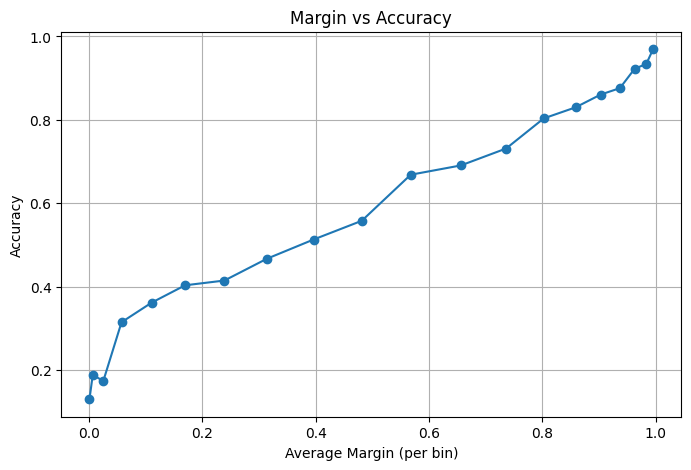

    avg_margin  accuracy  count
0     0.000738  0.130482    912
1     0.006532  0.188596    912
2     0.025205  0.174342    912
3     0.057376  0.315038    911
4     0.110377  0.361842    912
5     0.169552  0.403509    912
6     0.238936  0.414929    911
7     0.313838  0.467105    912
8     0.396223  0.513158    912
9     0.481412  0.558114    912
10    0.567769  0.668496    911
11    0.656321  0.690789    912
12    0.736288  0.731360    912
13    0.802694  0.803513    911
14    0.858934  0.830044    912
15    0.903324  0.860746    912
16    0.937020  0.875960    911
17    0.962938  0.922149    912
18    0.983719  0.934211    912
19    0.995679  0.969298    912


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def margin_vs_accuracy(P, y_pred, y_true, n_bins=20):
    # margin 계산
    sorted_probs = np.sort(P, axis=1)[:, ::-1]
    margins = sorted_probs[:, 0] - sorted_probs[:, 1]

    df = pd.DataFrame({
        "margin": margins,
        "pred": y_pred,
        "true": y_true
    })
    df["correct"] = (df["pred"] == df["true"]).astype(int)

    # margin 구간 나누기
    df["bin"] = pd.qcut(df["margin"], q=n_bins, duplicates="drop")

    # 구간별 accuracy
    grouped = df.groupby("bin").agg(
        avg_margin=("margin", "mean"),
        accuracy=("correct", "mean"),
        count=("correct", "size")
    ).reset_index(drop=True)

    # 시각화
    plt.figure(figsize=(8,5))
    plt.plot(grouped["avg_margin"], grouped["accuracy"], marker="o")
    plt.xlabel("Average Margin (per bin)")
    plt.ylabel("Accuracy")
    plt.title("Margin vs Accuracy")
    plt.grid(True)
    plt.show()

    return grouped

# 예시 실행 (Hungarian 이후 예측 기준)
result_table = margin_vs_accuracy(P_loaded, y_aligned_loaded, y_true, n_bins=20)
print(result_table)


In [22]:
import numpy as np

def accuracy_in_low_margin(P, y_pred, y_true, q=0.15):
    """
    P: (N, K) soft cluster probabilities
    y_pred: (N,) predicted labels (헝가리안 이후 y_aligned 권장)
    y_true: (N,) ground truth labels
    q: 하위 비율 (0.15 = 15%)
    """
    # margin 계산
    sorted_probs = np.sort(P, axis=1)[:, ::-1]
    margins = sorted_probs[:, 0] - sorted_probs[:, 1]

    # 임계값 구하기 (하위 q 백분위)
    cutoff = np.quantile(margins, q)

    # 하위 q% 데이터만 선택
    mask = margins <= cutoff
    acc = np.mean(y_pred[mask] == y_true[mask])

    return acc, cutoff, mask.sum()

# ----------------------------
# 실행 (Hungarian 이후 결과 기준)
# ----------------------------
acc10, cutoff10, n10 = accuracy_in_low_margin(P_loaded, y_aligned_loaded, y_true, q=0.10)
acc15, cutoff15, n15 = accuracy_in_low_margin(P_loaded, y_aligned_loaded, y_true, q=0.15)
acc25, cutoff25, n25 = accuracy_in_low_margin(P_loaded, y_aligned_loaded, y_true, q=0.25)

print(f"Bottom 10% (n={n10}, cutoff={cutoff10:.4f}) Accuracy: {acc10:.4f}")
print(f"Bottom 15% (n={n15}, cutoff={cutoff15:.4f}) Accuracy: {acc15:.4f}")
print(f"Bottom 25% (n={n25}, cutoff={cutoff25:.4f}) Accuracy: {acc25:.4f}")


Bottom 10% (n=1824, cutoff=0.0149) Accuracy: 0.1595
Bottom 15% (n=2736, cutoff=0.0369) Accuracy: 0.1645
Bottom 25% (n=4559, cutoff=0.1382) Accuracy: 0.2340


In [28]:
import numpy as np

def get_low_margin_indices(P, q=0.10):
    """
    P: (N, K) soft cluster probabilities
    q: 하위 비율 (0.10 = 10%)
    return: (indices, cutoff, n_selected)
    """
    sorted_probs = np.sort(P, axis=1)[:, ::-1]
    margins = sorted_probs[:, 0] - sorted_probs[:, 1]

    cutoff = np.quantile(margins, q)
    mask = margins <= cutoff
    indices = np.where(mask)[0]  # 인덱스 리스트 반환

    return indices, cutoff, mask.sum()

# ----------------------------
# 실행 (Hungarian 이후 예측 기준)
# ----------------------------
low10_indices, cutoff10, n10 = get_low_margin_indices(P_loaded, q=0.10)

print(f"Bottom 10% cutoff: {cutoff10:.4f}")
print(f"Selected {n10} samples as relabeling targets")
print("Example indices:", low10_indices[:20])  # 앞 20개만 보기


Bottom 10% cutoff: 0.0149
Selected 1824 samples as relabeling targets
Example indices: [ 37  41  42  52  54  63  76 104 106 107 110 125 127 130 135 142 165 173
 195 205]


### [5] LLM rationale

In [13]:
def build_prompt(original_text: str) -> str:
    return f"""You are tasked with inferring a latent topic representation from a given text. 
Your goal is to analyze the semantic content holistically and propose a concise label that reflects the underlying theme.

INPUT:
- text: "{original_text}"

TASK:
1. Derive a short latent topic label capturing the main semantic theme.
2. Provide a brief rationale (1–2 sentences) explaining the semantic basis for this label.
3. Extract 5–8 salient keywords that best characterize the text.
4. Assign a confidence score between 0 and 1, reflecting certainty in the labeling decision.

RESPONSE FORMAT (JSON only):
{{
  "label": "...",
  "rationale": "...",
  "keywords": ["...", "..."],
  "confidence": 0.0,
  "skip": false
}}"""


In [14]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [15]:
def _strip_code_fences(s: str) -> str:
    # ```json ... ``` 제거
    return re.sub(r"^```(?:json)?\s*|\s*```$", "", s.strip(), flags=re.IGNORECASE|re.DOTALL)

def _json_recover(s: str):
    """
    아주 가벼운 복구기: true/false/null 소문자 → 파이썬/JSON 호환, 꼬리 콤마 제거 등.
    완벽하지 않지만 간단한 실수는 복구.
    """
    s = _strip_code_fences(s)
    # 흔한 실수들 보정
    s = s.replace("\t", " ")
    # 따옴표 누락/꼬리콤마는 완전 해결 어렵지만 간단히 시도
    s = re.sub(r",\s*}", "}", s)
    s = re.sub(r",\s*]", "]", s)
    # json.loads로 최종 시도
    return json.loads(s)

def call_llm_json(prompt: str, max_retries: int = 3, sleep_base: float = 0.5) -> dict:
    last_err = None
    for attempt in range(1, max_retries+1):
        try:
            resp = client.chat.completions.create(
                model='gpt-4o',
                messages=[{"role": "user", "content": prompt}],
                temperature=0.2,
                response_format={"type": "json_object"},
            )
            content = resp.choices[0].message.content
            return json.loads(content)
        except Exception as e:
            last_err = e
            # 한 번 더 복구 시도: content를 문자열로 받을 수 있으면 파싱
            try:
                if 'content' in locals() and isinstance(content, str):
                    return _json_recover(content)
            except Exception:
                pass
            # backoff
            time.sleep(sleep_base * attempt)
    raise RuntimeError(f"LLM call failed after retries: {repr(last_err)}")

In [16]:
text_col = "cleaned_text" if "cleaned_text" in df.columns else "text"
assert text_col in df.columns, f"'{text_col}' column is required in df."

for col in ["llm_label", "llm_rationale", "llm_keywords", "llm_confidence", "llm_skip"]:
    if col not in df.columns:
        df[col] = np.nan

In [27]:
print(df.columns)              # 실제 df 컬럼 확인
print(df.loc[low10_indices[:5], "text"])  # text 값 몇 개 확인


Index(['text', 'label_id', 'label_name', 'cleaned_text', 'cluster_label'], dtype='object')
37    in article writes proof that the entire privat...
41    i am looking for a package which takes as inpu...
42    in article peter j demko writes oh dear time f...
52    in article very old freshman vof writes anythi...
54    in article lawrence b keys writes don t worry ...
Name: text, dtype: object


In [26]:
import json
from tqdm import tqdm

out_path = "/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/cluster_20ng_llm.csv"

for i, ridx in enumerate(tqdm(low10_indices, desc="LLM rationale", total=len(low10_indices))):
    text_val = df.at[ridx, "text"]
    text = str(text_val).strip() if isinstance(text_val, str) else ""
    
    if not text:
        # 빈 텍스트면 skip
        df.at[ridx, "llm_label"] = ""
        df.at[ridx, "llm_rationale"] = ""
        df.at[ridx, "llm_keywords"] = json.dumps([])
        df.at[ridx, "llm_confidence"] = 0.0
        df.at[ridx, "llm_skip"] = True
        continue

    prompt = build_prompt(text)
    try:
        j = call_llm_json(prompt, max_retries=3)
        # 필드 안전 추출
        label = str(j.get("label", "")).strip()
        rationale = str(j.get("rationale", "")).strip()
        keywords = j.get("keywords", [])
        if not isinstance(keywords, list):
            keywords = [str(keywords)]
        confidence = float(j.get("confidence", 0.0))
        skip = bool(j.get("skip", False))
    except Exception as e:
        print(f"[ERROR] idx={ridx}, text[:50]={text[:50]!r}, error={e}")
        label, rationale, keywords, confidence, skip = "", "", [], 0.0, True

    # df에 기록
    df.at[ridx, "llm_label"] = label
    df.at[ridx, "llm_rationale"] = rationale
    df.at[ridx, "llm_keywords"] = json.dumps(keywords, ensure_ascii=False)
    df.at[ridx, "llm_confidence"] = confidence
    df.at[ridx, "llm_skip"] = skip

# 마지막 저장
df.to_csv(out_path, index=False)
print(f"[Done] Saved with LLM fields → {out_path}")

# -----------------------------
# (옵션) 결과 요약 확인
# -----------------------------
sub = df.loc[low10_indices, ["llm_label", "llm_rationale", "llm_keywords", "llm_confidence", "llm_skip"]]
print(sub.head(10))


LLM rationale:   0%|          | 0/1824 [00:00<?, ?it/s]


NameError: name 'build_prompt' is not defined

In [19]:
df.to_csv('/home/ys0660/2507Sub/textclustering/0915/Topicker/tester_relabel_1.csv')

### [6] 하나의 임베딩 벡터로 만들어보기

In [33]:
from get_embeddings import get_embeddings

In [32]:
relabel_embeddings = embeddings["X"][low10_indices]

In [38]:
# way 1. 원본 텍스트 + llm rationale 1:1
texts = sub["llm_rationale"].astype(str).tolist()
X = get_embeddings(texts)

Embedding: 100%|██████████| 1824/1824 [10:53<00:00,  2.79it/s]


=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824


In [42]:
embed = embeddings["X"].copy()
embed[low10_indices] = X

In [9]:
from soft_kmeans import run_soft_kmeans
import numpy as np

# soft k-means 실행
P, C, y_pred_hard = run_soft_kmeans(embed, n_clusters=20)

print("P shape:", P.shape)
print("C shape:", C.shape)
print("y_pred_hard shape:", y_pred_hard.shape)

# 저장도 가능
np.savez("soft_results.npz", P=P, C=C, y_pred_hard=y_pred_hard)


P shape: (18235, 20)
C shape: (20, 1536)
y_pred_hard shape: (18235,)


In [12]:
from hungarian_align import hungarian_align, save_soft_results
y_true = df["label_id"].to_numpy()
y_pred_aligned, mapping = hungarian_align(y_pred_hard, y_true, P, C)

In [45]:
from evaluation import evaluate_models

# 평가 실행
metrics = evaluate_models(
    y_true,
    preds={"aligned": y_pred_aligned},
    texts=df["text"].tolist(),
    topn=10,
    save_topic_path="/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/topic_words.txt"
)

# 결과 출력
for model, scores in metrics.items():
    print(model, scores)

aligned {'P1': 0.580806142034549, 'ARI': 0.39396667086637366, 'NMI': 0.5588066717444886, 'TD': 0.515}


In [39]:
# way 2. 원본 텍스트 + llm label 1:1
texts = sub["llm_label"].astype(str).tolist()
X_label = get_embeddings(texts)

Embedding: 100%|██████████| 1824/1824 [10:15<00:00,  2.96it/s]


=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824


In [46]:
embed = embeddings["X"].copy()
embed[low10_indices] = X_label

# soft k-means 실행
P, C, y_pred_hard = run_soft_kmeans(embed, n_clusters=20)

print("P shape:", P.shape)
print("C shape:", C.shape)
print("y_pred_hard shape:", y_pred_hard.shape)

y_true = df["label_id"].to_numpy()
y_pred_aligned, mapping = hungarian_align(y_pred_hard, y_true, P, C)

# 평가 실행
metrics = evaluate_models(
    y_true,
    preds={"aligned": y_pred_aligned},
    texts=df["text"].tolist(),
    topn=10,
    save_topic_path="/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/topic_words.txt"
)

# 결과 출력
for model, scores in metrics.items():
    print(model, scores)

P shape: (18235, 20)
C shape: (20, 1536)
y_pred_hard shape: (18235,)
aligned {'P1': 0.5951192761173567, 'ARI': 0.41652900356540923, 'NMI': 0.5725938573428366, 'TD': 0.51}


In [41]:
# way 3. 원본 텍스트 + llm rationale&label 1:1
texts = (sub["llm_rationale"].fillna("").astype(str) + " " + 
         sub["llm_label"].fillna("").astype(str)).tolist()

print(len(texts))    # 샘플 개수

X_concat = get_embeddings(texts)
print(texts[0])      # 첫 번째 concat 결과
print(X_concat.shape)       


1824


Embedding: 100%|██████████| 1824/1824 [10:24<00:00,  2.92it/s]


=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824
The text critiques inefficiencies in the private sector and government health insurance, while also questioning the authenticity of intellectual convictions that may be influenced by vested interests. Critique of Economic and Intellectual Systems
(1824, 1536)


In [47]:
embed = embeddings["X"].copy()
embed[low10_indices] = X_concat

# soft k-means 실행
P, C, y_pred_hard = run_soft_kmeans(embed, n_clusters=20)

print("P shape:", P.shape)
print("C shape:", C.shape)
print("y_pred_hard shape:", y_pred_hard.shape)

y_true = df["label_id"].to_numpy()
y_pred_aligned, mapping = hungarian_align(y_pred_hard, y_true, P, C)

# 평가 실행
metrics = evaluate_models(
    y_true,
    preds={"aligned": y_pred_aligned},
    texts=df["text"].tolist(),
    topn=10,
    save_topic_path="/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/topic_words.txt"
)

# 결과 출력
for model, scores in metrics.items():
    print(model, scores)

P shape: (18235, 20)
C shape: (20, 1536)
y_pred_hard shape: (18235,)
aligned {'P1': 0.5517959967096243, 'ARI': 0.3927723922406111, 'NMI': 0.5550189108735777, 'TD': 0.52}


In [14]:
from evaluation import evaluate_models

embed = embeddings["X"].copy()

# soft k-means 실행
P, C, y_pred_hard = run_soft_kmeans(embed, n_clusters=20)

print("P shape:", P.shape)
print("C shape:", C.shape)
print("y_pred_hard shape:", y_pred_hard.shape)

y_true = df["label_id"].to_numpy()
y_pred_aligned, mapping = hungarian_align(y_pred_hard, y_true, P, C)

# 평가 실행
metrics = evaluate_models(
    y_true,
    preds={"aligned": y_pred_aligned},
    texts=df["text"].tolist(),
    topn=10,
    save_topic_path="/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/topic_words.txt"
)

# 결과 출력
for model, scores in metrics.items():
    print(model, scores)

P shape: (18235, 20)
C shape: (20, 1536)
y_pred_hard shape: (18235,)
aligned {'P1': 0.5549218535782835, 'ARI': 0.37680657914715565, 'NMI': 0.5543414591377103, 'TD': 0.54}


In [18]:
len(embed)

18235

In [29]:
df = pd.read_csv('/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/cluster_20ng_llm.csv')

In [30]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score

from get_embeddings import get_embeddings
from soft_kmeans import run_soft_kmeans
from hungarian_align import hungarian_align

# -----------------------
# 설정
# -----------------------
K = 20                              # 클러스터 개수 (20NG라면 20)
USE_L2_NORMALIZED_MEAN = True       # True: L2 정규화 후 평균 / False: 단순 평균

# df: 반드시 'label_id', 'text' 포함
# embeddings: np.load(...) 결과 (키: "X")
# low10_indices: 재라벨 대상 인덱스 (np.array of int)
assert isinstance(low10_indices, (list, np.ndarray))
low10_indices = np.asarray(low10_indices)

X_all_orig = embeddings["X"]                  # (N, 1536)
y_true = df["label_id"].to_numpy()

# -----------------------
# 1) BEFORE: 기존 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_bef, C_bef, y_pred_hard_bef = run_soft_kmeans(X_all_orig, n_clusters=K)
y_pred_aligned_bef, mapping_bef = hungarian_align(y_pred_hard_bef, y_true, P_bef, C_bef)

acc_before_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_bef[low10_indices]
)
print(f"[Before] accuracy on relabel targets (n={len(low10_indices)}): {acc_before_targets:.4f}")

# -----------------------
# 2) LLM 임베딩 준비: sub['llm_rationale']를 사용
#    (필요하면 llm_label까지 이어붙여도 OK)
# -----------------------
# 예) rationale만
texts = df.iloc[low10_indices]["llm_rationale"].fillna("").astype(str).tolist()

# 만약 label+rationale을 합치고 싶다면:
# texts = (df.iloc[low10_indices]["llm_label"].fillna("").astype(str) + " " +
#          df.iloc[low10_indices]["llm_rationale"].fillna("").astype(str)).tolist()

X_llm = get_embeddings(texts)                # (M, 1536)  M=len(low10_indices)
X_orig_targets = X_all_orig[low10_indices]   # (M, 1536)

# -----------------------
# 3) 두 벡터 결합 (평균)
# -----------------------
if USE_L2_NORMALIZED_MEAN:
    X_a = normalize(X_orig_targets)  # 행 단위 L2 정규화
    X_b = normalize(X_llm)
    X_combined = normalize(X_a + X_b)
else:
    X_combined = (X_orig_targets + X_llm) / 2.0

# -----------------------
# 4) 업데이트된 전체 임베딩 구성 (relabel 대상만 교체)
# -----------------------
X_all_updated = X_all_orig.copy()
X_all_updated[low10_indices] = X_combined

# -----------------------
# 5) AFTER: 업데이트 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_aft, C_aft, y_pred_hard_aft = run_soft_kmeans(X_all_updated, n_clusters=K)
y_pred_aligned_aft, mapping_aft = hungarian_align(y_pred_hard_aft, y_true, P_aft, C_aft)

acc_after_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_aft[low10_indices]
)

print(f"[After ] accuracy on relabel targets (n={len(low10_indices)}): {acc_after_targets:.4f}")
print(f"[Delta ] improvement on targets: {acc_after_targets - acc_before_targets:+.4f}")



[Before] accuracy on relabel targets (n=1824): 0.1919


Embedding: 100%|██████████| 1824/1824 [12:17<00:00,  2.47it/s]



=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824
[After ] accuracy on relabel targets (n=1824): 0.2785
[Delta ] improvement on targets: +0.0866


In [32]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# low10 대상에서의 정오표
bef_correct = (y_pred_aligned_bef[low10_indices] == y_true[low10_indices])
aft_correct = (y_pred_aligned_aft[low10_indices] == y_true[low10_indices])

# b: before 틀렸는데 after 맞음, c: before 맞았는데 after 틀림
b = np.sum((~bef_correct) & (aft_correct))
c = np.sum((bef_correct) & (~aft_correct))
table = [[0, b],
         [c, 0]]

result = mcnemar(table, exact=False, correction=True)
print(f"McNemar b={b}, c={c}, statistic={result.statistic:.3f}, p={result.pvalue:.3g}")


McNemar b=309, c=151, statistic=53.585, p=2.48e-13


In [33]:
import pandas as pd

df_eval = pd.DataFrame({
    "y_true": y_true[low10_indices],
    "bef": y_pred_aligned_bef[low10_indices],
    "aft": y_pred_aligned_aft[low10_indices],
})
df_eval["bef_ok"] = (df_eval["bef"] == df_eval["y_true"]).astype(int)
df_eval["aft_ok"] = (df_eval["aft"] == df_eval["y_true"]).astype(int)
df_eval["delta"] = df_eval["aft_ok"] - df_eval["bef_ok"]

by_class = df_eval.groupby("y_true").agg(
    n=("y_true","size"),
    acc_bef=("bef_ok","mean"),
    acc_aft=("aft_ok","mean"),
    delta=("delta","mean"),
).sort_values("delta", ascending=False)

print(by_class.head(10))
print(by_class.tail(10))


          n   acc_bef   acc_aft     delta
y_true                                   
18      227  0.396476  0.991189  0.594714
9       114  0.043860  0.385965  0.342105
5        42  0.261905  0.500000  0.238095
4        51  0.274510  0.490196  0.215686
10       84  0.071429  0.273810  0.202381
6        78  0.282051  0.423077  0.141026
15       44  0.068182  0.204545  0.136364
11      109  0.036697  0.165138  0.128440
1        64  0.234375  0.312500  0.078125
13       80  0.087500  0.150000  0.062500
          n   acc_bef   acc_aft     delta
y_true                                   
16      135  0.059259  0.103704  0.044444
3        31  0.096774  0.129032  0.032258
14      117  0.111111  0.128205  0.017094
17       75  0.026667  0.040000  0.013333
0       139  0.000000  0.007194  0.007194
19       93  0.000000  0.000000  0.000000
12       53  0.113208  0.094340 -0.018868
7        83  0.168675  0.144578 -0.024096
2        57  0.228070  0.017544 -0.210526
8       148  0.770270  0.155405 -0

In [34]:
def top2_margin(P):
    s = np.sort(P, axis=1)[:, ::-1]
    return s[:,0] - s[:,1]

m_bef = top2_margin(P_bef)[low10_indices]
m_aft = top2_margin(P_aft)[low10_indices]

import numpy as np
print("Margin mean (before -> after): ", np.mean(m_bef), "->", np.mean(m_aft))
print("Margin median (before -> after): ", np.median(m_bef), "->", np.median(m_aft))


Margin mean (before -> after):  0.0012889425 -> 0.0024156254
Margin median (before -> after):  0.0010328181 -> 0.0023253933


In [40]:
from sklearn.metrics import accuracy_score
from evaluation import evaluate_models  # ext_metrics 포함 가정

# 전체 accuracy (전/후)
acc_before_all = accuracy_score(y_true, y_pred_aligned_bef)
acc_after_all  = accuracy_score(y_true, y_pred_aligned_aft)

print(f"[Overall] Accuracy before: {acc_before_all:.4f}")
print(f"[Overall] Accuracy after : {acc_after_all:.4f}")
print(f"[Overall] ΔAccuracy      : {acc_after_all - acc_before_all:+.4f}")

# 외부/내부 지표 한 번에 (evaluation.py 사용)
metrics_bef = evaluate_models(
    y_true,
    preds={"before": y_pred_aligned_bef},
    # topics_words 인자를 받는 버전이면 아래 두 줄도 사용 가능
    # texts=df["text"].tolist(),
    # topn=10
)
metrics_aft = evaluate_models(
    y_true,
    preds={"after": y_pred_aligned_aft},
    # texts=df["text"].tolist(),
    # topn=10
)

print("\n=== Overall metrics ===")
print("before:", metrics_bef["before"])
print("after :", metrics_aft["after"])


[Overall] Accuracy before: 0.5315
[Overall] Accuracy after : 0.5800
[Overall] ΔAccuracy      : +0.0485

=== Overall metrics ===
before: {'P1': 0.5549218535782835, 'ARI': 0.37680657914715565, 'NMI': 0.5543414591377103, 'TD': None}
after : {'P1': 0.5971483411022759, 'ARI': 0.4133780165599032, 'NMI': 0.577099660442086, 'TD': None}


label만 쓸 때

In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score

from get_embeddings import get_embeddings
from soft_kmeans import run_soft_kmeans
from hungarian_align import hungarian_align

# -----------------------
# 설정
# -----------------------
K = 20                              # 클러스터 개수 (20NG라면 20)
USE_L2_NORMALIZED_MEAN = True       # True: L2 정규화 후 평균 / False: 단순 평균

# df: 반드시 'label_id', 'text' 포함
# embeddings: np.load(...) 결과 (키: "X")
# low10_indices: 재라벨 대상 인덱스 (np.array of int)
assert isinstance(low10_indices, (list, np.ndarray))
low10_indices = np.asarray(low10_indices)

X_all_orig = embeddings["X"]                  # (N, 1536)
y_true = df["label_id"].to_numpy()

# -----------------------
# 1) BEFORE: 기존 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_bef, C_bef, y_pred_hard_bef = run_soft_kmeans(X_all_orig, n_clusters=K)
y_pred_aligned_bef, mapping_bef = hungarian_align(y_pred_hard_bef, y_true, P_bef, C_bef)

acc_before_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_bef[low10_indices]
)
print(f"[Before] accuracy on relabel targets (n={len(low10_indices)}): {acc_before_targets:.4f}")

# -----------------------
# 2) LLM 임베딩 준비: sub['llm_rationale']를 사용
#    (필요하면 llm_label까지 이어붙여도 OK)
# -----------------------
# 예) rationale만
texts = df.iloc[low10_indices]["llm_label"].fillna("").astype(str).tolist()

# 만약 label+rationale을 합치고 싶다면:
# texts = (df.iloc[low10_indices]["llm_label"].fillna("").astype(str) + " " +
#          df.iloc[low10_indices]["llm_rationale"].fillna("").astype(str)).tolist()

X_llm = get_embeddings(texts)                # (M, 1536)  M=len(low10_indices)
X_orig_targets = X_all_orig[low10_indices]   # (M, 1536)

# -----------------------
# 3) 두 벡터 결합 (평균)
# -----------------------
if USE_L2_NORMALIZED_MEAN:
    X_a = normalize(X_orig_targets)  # 행 단위 L2 정규화
    X_b = normalize(X_llm)
    X_combined = normalize(X_a + X_b)
else:
    X_combined = (X_orig_targets + X_llm) / 2.0

# -----------------------
# 4) 업데이트된 전체 임베딩 구성 (relabel 대상만 교체)
# -----------------------
X_all_updated = X_all_orig.copy()
X_all_updated[low10_indices] = X_combined

# -----------------------
# 5) AFTER: 업데이트 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_aft, C_aft, y_pred_hard_aft = run_soft_kmeans(X_all_updated, n_clusters=K)
y_pred_aligned_aft, mapping_aft = hungarian_align(y_pred_hard_aft, y_true, P_aft, C_aft)

acc_after_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_aft[low10_indices]
)

print(f"[After ] accuracy on relabel targets (n={len(low10_indices)}): {acc_after_targets:.4f}")
print(f"[Delta ] improvement on targets: {acc_after_targets - acc_before_targets:+.4f}")



[Before] accuracy on relabel targets (n=1824): 0.1919


Embedding: 100%|██████████| 1824/1824 [11:11<00:00,  2.72it/s]



=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824
[After ] accuracy on relabel targets (n=1824): 0.3054
[Delta ] improvement on targets: +0.1135


In [42]:
from sklearn.metrics import accuracy_score
from evaluation import evaluate_models  # ext_metrics 포함 가정

# 전체 accuracy (전/후)
acc_before_all = accuracy_score(y_true, y_pred_aligned_bef)
acc_after_all  = accuracy_score(y_true, y_pred_aligned_aft)

print(f"[Overall] Accuracy before: {acc_before_all:.4f}")
print(f"[Overall] Accuracy after : {acc_after_all:.4f}")
print(f"[Overall] ΔAccuracy      : {acc_after_all - acc_before_all:+.4f}")

# 외부/내부 지표 한 번에 (evaluation.py 사용)
metrics_bef = evaluate_models(
    y_true,
    preds={"before": y_pred_aligned_bef},
    # topics_words 인자를 받는 버전이면 아래 두 줄도 사용 가능
    # texts=df["text"].tolist(),
    # topn=10
)
metrics_aft = evaluate_models(
    y_true,
    preds={"after": y_pred_aligned_aft},
    # texts=df["text"].tolist(),
    # topn=10
)

print("\n=== Overall metrics ===")
print("before:", metrics_bef["before"])
print("after :", metrics_aft["after"])


[Overall] Accuracy before: 0.5315
[Overall] Accuracy after : 0.6059
[Overall] ΔAccuracy      : +0.0744

=== Overall metrics ===
before: {'P1': 0.5549218535782835, 'ARI': 0.37680657914715565, 'NMI': 0.5543414591377103, 'TD': None}
after : {'P1': 0.6100904853304085, 'ARI': 0.4373972709811347, 'NMI': 0.5821669720805099, 'TD': None}


두개 다 쓸 때

In [43]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score

from get_embeddings import get_embeddings
from soft_kmeans import run_soft_kmeans
from hungarian_align import hungarian_align

# -----------------------
# 설정
# -----------------------
K = 20                              # 클러스터 개수 (20NG라면 20)
USE_L2_NORMALIZED_MEAN = True       # True: L2 정규화 후 평균 / False: 단순 평균

# df: 반드시 'label_id', 'text' 포함
# embeddings: np.load(...) 결과 (키: "X")
# low10_indices: 재라벨 대상 인덱스 (np.array of int)
assert isinstance(low10_indices, (list, np.ndarray))
low10_indices = np.asarray(low10_indices)

X_all_orig = embeddings["X"]                  # (N, 1536)
y_true = df["label_id"].to_numpy()

# -----------------------
# 1) BEFORE: 기존 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_bef, C_bef, y_pred_hard_bef = run_soft_kmeans(X_all_orig, n_clusters=K)
y_pred_aligned_bef, mapping_bef = hungarian_align(y_pred_hard_bef, y_true, P_bef, C_bef)

acc_before_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_bef[low10_indices]
)
print(f"[Before] accuracy on relabel targets (n={len(low10_indices)}): {acc_before_targets:.4f}")

# -----------------------
# 2) LLM 임베딩 준비: sub['llm_rationale']를 사용
#    (필요하면 llm_label까지 이어붙여도 OK)
# -----------------------
# 예) rationale만
labels     = df.iloc[low10_indices]["llm_label"].fillna("").astype(str)
rationales = df.iloc[low10_indices]["llm_rationale"].fillna("").astype(str)

# "Label: ... Rationale: ..." 형태로 결합 (둘 중 하나가 비어도 안전)
texts = ("Label: " + labels.str.strip() + " | Rationale: " + rationales.str.strip()).tolist()

# 만약 label+rationale을 합치고 싶다면:
# texts = (df.iloc[low10_indices]["llm_label"].fillna("").astype(str) + " " +
#          df.iloc[low10_indices]["llm_rationale"].fillna("").astype(str)).tolist()

X_llm = get_embeddings(texts)                # (M, 1536)  M=len(low10_indices)
X_orig_targets = X_all_orig[low10_indices]   # (M, 1536)

# -----------------------
# 3) 두 벡터 결합 (평균)
# -----------------------
if USE_L2_NORMALIZED_MEAN:
    X_a = normalize(X_orig_targets)  # 행 단위 L2 정규화
    X_b = normalize(X_llm)
    X_combined = normalize(X_a + X_b)
else:
    X_combined = (X_orig_targets + X_llm) / 2.0

# -----------------------
# 4) 업데이트된 전체 임베딩 구성 (relabel 대상만 교체)
# -----------------------
X_all_updated = X_all_orig.copy()
X_all_updated[low10_indices] = X_combined

# -----------------------
# 5) AFTER: 업데이트 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_aft, C_aft, y_pred_hard_aft = run_soft_kmeans(X_all_updated, n_clusters=K)
y_pred_aligned_aft, mapping_aft = hungarian_align(y_pred_hard_aft, y_true, P_aft, C_aft)

acc_after_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_aft[low10_indices]
)

print(f"[After ] accuracy on relabel targets (n={len(low10_indices)}): {acc_after_targets:.4f}")
print(f"[Delta ] improvement on targets: {acc_after_targets - acc_before_targets:+.4f}")



[Before] accuracy on relabel targets (n=1824): 0.1919


Embedding: 100%|██████████| 1824/1824 [11:04<00:00,  2.74it/s]



=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824
[After ] accuracy on relabel targets (n=1824): 0.2719
[Delta ] improvement on targets: +0.0800


In [44]:
from sklearn.metrics import accuracy_score
from evaluation import evaluate_models  # ext_metrics 포함 가정

# 전체 accuracy (전/후)
acc_before_all = accuracy_score(y_true, y_pred_aligned_bef)
acc_after_all  = accuracy_score(y_true, y_pred_aligned_aft)

print(f"[Overall] Accuracy before: {acc_before_all:.4f}")
print(f"[Overall] Accuracy after : {acc_after_all:.4f}")
print(f"[Overall] ΔAccuracy      : {acc_after_all - acc_before_all:+.4f}")

# 외부/내부 지표 한 번에 (evaluation.py 사용)
metrics_bef = evaluate_models(
    y_true,
    preds={"before": y_pred_aligned_bef},
    # topics_words 인자를 받는 버전이면 아래 두 줄도 사용 가능
    # texts=df["text"].tolist(),
    # topn=10
)
metrics_aft = evaluate_models(
    y_true,
    preds={"after": y_pred_aligned_aft},
    # texts=df["text"].tolist(),
    # topn=10
)

print("\n=== Overall metrics ===")
print("before:", metrics_bef["before"])
print("after :", metrics_aft["after"])


[Overall] Accuracy before: 0.5315
[Overall] Accuracy after : 0.5409
[Overall] ΔAccuracy      : +0.0094

=== Overall metrics ===
before: {'P1': 0.5549218535782835, 'ARI': 0.37680657914715565, 'NMI': 0.5543414591377103, 'TD': None}
after : {'P1': 0.5607348505621058, 'ARI': 0.4012703585916916, 'NMI': 0.5644767870112196, 'TD': None}


### Loop

In [2]:
import pandas as pd

In [14]:
# 1. 클러스터의 argmax값을 붙인 csv파일을 로드
df = pd.read_csv('/home/ys0660/2507Sub/textclustering/0915/Topicker/tester_relabel_1.csv')
df.head()

,Unnamed: 0,text,label_id,label_name,cleaned_text,cluster_label,llm_label,llm_rationale,llm_keywords,llm_confidence,llm_skip
0,0,i am sure some bashers of pens fans are pretty...,10,rec.sport.hockey,sure basher pen fan confused lack kind post re...,10,NaN,NaN,NaN,NaN,NaN
1,1,my brother is in the market for a high perform...,3,comp.sys.ibm.pc.hardware,brother market high performance video card loc...,3,NaN,NaN,NaN,NaN,NaN
2,2,the student of regional killings alias davidia...,17,talk.politics.mideast,student regional killing alias davidian davidi...,17,NaN,NaN,NaN,NaN,NaN
3,3,in article wayne smith writes think it s the s...,3,comp.sys.ibm.pc.hardware,scsi card dma transfer disk scsi card transfer...,3,NaN,NaN,NaN,NaN,NaN
4,4,1 i have an old jasmine drive which i cannot u...,4,comp.sys.mac.hardware,old jasmine drive new understanding driver mod...,3,NaN,NaN,NaN,NaN,NaN


In [15]:
P_loaded, C_loaded, mapping_loaded, y_hard_loaded, y_aligned_loaded = load_soft_results("/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/soft_results.npz")

In [16]:
def get_low_margin_indices(P, q=0.10):
    """
    P: (N, K) soft cluster probabilities
    q: 하위 비율 (0.10 = 10%)
    return: (indices, cutoff, n_selected)
    """
    sorted_probs = np.sort(P, axis=1)[:, ::-1]
    margins = sorted_probs[:, 0] - sorted_probs[:, 1]

    cutoff = np.quantile(margins, q)
    mask = margins <= cutoff
    indices = np.where(mask)[0]  # 인덱스 리스트 반환

    return indices, cutoff, mask.sum()

In [17]:
low10_indices, cutoff10, n10 = get_low_margin_indices(P_loaded, q=0.10)

In [18]:
embeddings = np.load('/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/embeddings.npz')

In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score

from get_embeddings import get_embeddings
from soft_kmeans import run_soft_kmeans
from hungarian_align import hungarian_align

# -----------------------
# 설정
# -----------------------
K = 20                              # 클러스터 개수 (20NG라면 20)
USE_L2_NORMALIZED_MEAN = True       # True: L2 정규화 후 평균 / False: 단순 평균

# df: 반드시 'label_id', 'text' 포함
# embeddings: np.load(...) 결과 (키: "X")
# low10_indices: 재라벨 대상 인덱스 (np.array of int)
assert isinstance(low10_indices, (list, np.ndarray))
low10_indices = np.asarray(low10_indices)

X_all_orig = embeddings["X"]                  # (N, 1536)
y_true = df["label_id"].to_numpy()

# -----------------------
# 1) BEFORE: 기존 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_bef, C_bef, y_pred_hard_bef = run_soft_kmeans(X_all_orig, n_clusters=K)
y_pred_aligned_bef, mapping_bef = hungarian_align(y_pred_hard_bef, y_true, P_bef, C_bef)

acc_before_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_bef[low10_indices]
)
print(f"[Before] accuracy on relabel targets (n={len(low10_indices)}): {acc_before_targets:.4f}")

# -----------------------
# 2) LLM 임베딩 준비: sub['llm_rationale']를 사용
#    (필요하면 llm_label까지 이어붙여도 OK)
# -----------------------
# 예) rationale만
texts = df.iloc[low10_indices]["llm_label"].fillna("").astype(str).tolist()

# 만약 label+rationale을 합치고 싶다면:
# texts = (df.iloc[low10_indices]["llm_label"].fillna("").astype(str) + " " +
#          df.iloc[low10_indices]["llm_rationale"].fillna("").astype(str)).tolist()

X_llm = get_embeddings(texts)                # (M, 1536)  M=len(low10_indices)
X_orig_targets = X_all_orig[low10_indices]   # (M, 1536)

# -----------------------
# 3) 두 벡터 결합 (평균)
# -----------------------
if USE_L2_NORMALIZED_MEAN:
    X_a = normalize(X_orig_targets)  # 행 단위 L2 정규화
    X_b = normalize(X_llm)
    X_combined = normalize(X_a + X_b)
else:
    X_combined = (X_orig_targets + X_llm) / 2.0

# -----------------------
# 4) 업데이트된 전체 임베딩 구성 (relabel 대상만 교체)
# -----------------------
X_all_updated = X_all_orig.copy()
X_all_updated[low10_indices] = X_combined

# -----------------------
# 5) AFTER: 업데이트 임베딩으로 soft k-means → 헝가리안 → accuracy(대상만)
# -----------------------
P_aft, C_aft, y_pred_hard_aft = run_soft_kmeans(X_all_updated, n_clusters=K)
y_pred_aligned_aft, mapping_aft = hungarian_align(y_pred_hard_aft, y_true, P_aft, C_aft)

acc_after_targets = accuracy_score(
    y_true[low10_indices],
    y_pred_aligned_aft[low10_indices]
)

print(f"[After ] accuracy on relabel targets (n={len(low10_indices)}): {acc_after_targets:.4f}")
print(f"[Delta ] improvement on targets: {acc_after_targets - acc_before_targets:+.4f}")



[Before] accuracy on relabel targets (n=1824): 0.1919


Embedding: 100%|██████████| 1824/1824 [10:49<00:00,  2.81it/s]



=== Embedding Summary ===
Total inputs   : 1824
OK             : 1824
Empty texts    : 0
API failures   : 0
Kept (non-zero): 1824
[After ] accuracy on relabel targets (n=1824): 0.3054
[Delta ] improvement on targets: +0.1135


In [20]:
from sklearn.metrics import accuracy_score
from evaluation import evaluate_models  # ext_metrics 포함 가정

# 전체 accuracy (전/후)
acc_before_all = accuracy_score(y_true, y_pred_aligned_bef)
acc_after_all  = accuracy_score(y_true, y_pred_aligned_aft)

print(f"[Overall] Accuracy before: {acc_before_all:.4f}")
print(f"[Overall] Accuracy after : {acc_after_all:.4f}")
print(f"[Overall] ΔAccuracy      : {acc_after_all - acc_before_all:+.4f}")

# 외부/내부 지표 한 번에 (evaluation.py 사용)
metrics_bef = evaluate_models(
    y_true,
    preds={"before": y_pred_aligned_bef},
    # topics_words 인자를 받는 버전이면 아래 두 줄도 사용 가능
    # texts=df["text"].tolist(),
    # topn=10
)
metrics_aft = evaluate_models(
    y_true,
    preds={"after": y_pred_aligned_aft},
    # texts=df["text"].tolist(),
    # topn=10
)

print("\n=== Overall metrics ===")
print("before:", metrics_bef["before"])
print("after :", metrics_aft["after"])


[Overall] Accuracy before: 0.5315
[Overall] Accuracy after : 0.5396
[Overall] ΔAccuracy      : +0.0081

=== Overall metrics ===
before: {'P1': 0.5549218535782835, 'ARI': 0.37680657914715565, 'NMI': 0.5543414591377103, 'TD': None}
after : {'P1': 0.5606251713737318, 'ARI': 0.4002404533398686, 'NMI': 0.5637223581103451, 'TD': None}
